In [3]:
# Step 1: Load the Iris (petal) dataset
from sklearn.datasets import load_iris
import pandas as pd

# Load the dataset
data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Step 2: Explore the Dataset
Let's examine the structure, check for missing values, and get a summary of the features.

In [4]:
# Display the shape of the dataset
print('Shape of dataset:', df.shape)

# Show basic statistics
display(df.describe())

# Check for missing values
print('Missing values in each column:')
print(df.isnull().sum())

Shape of dataset: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


Missing values in each column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


## Step 3: Visualize the Data
Let's plot some feature distributions and pairwise relationships to better understand the dataset.

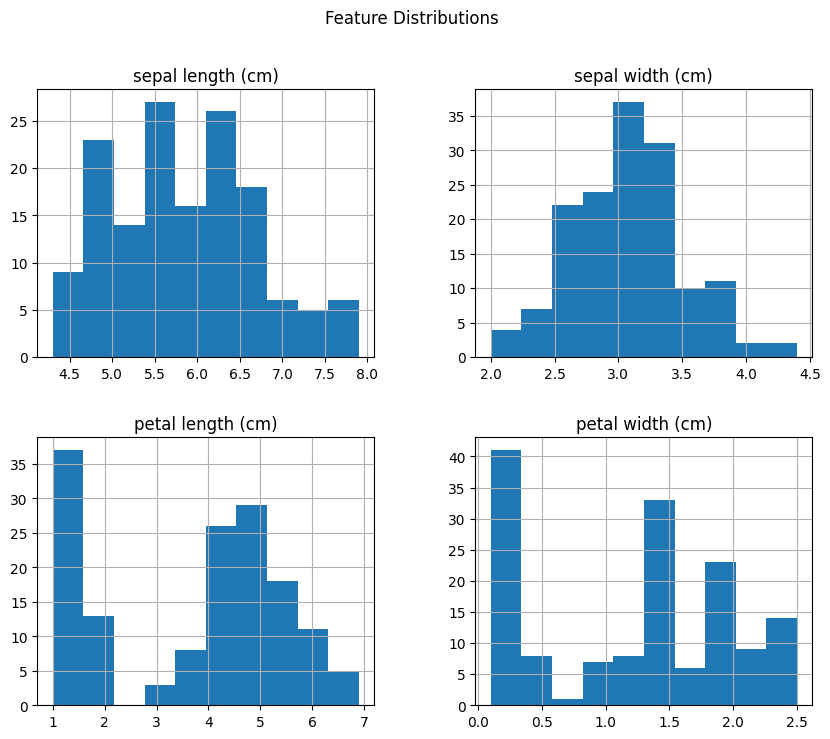

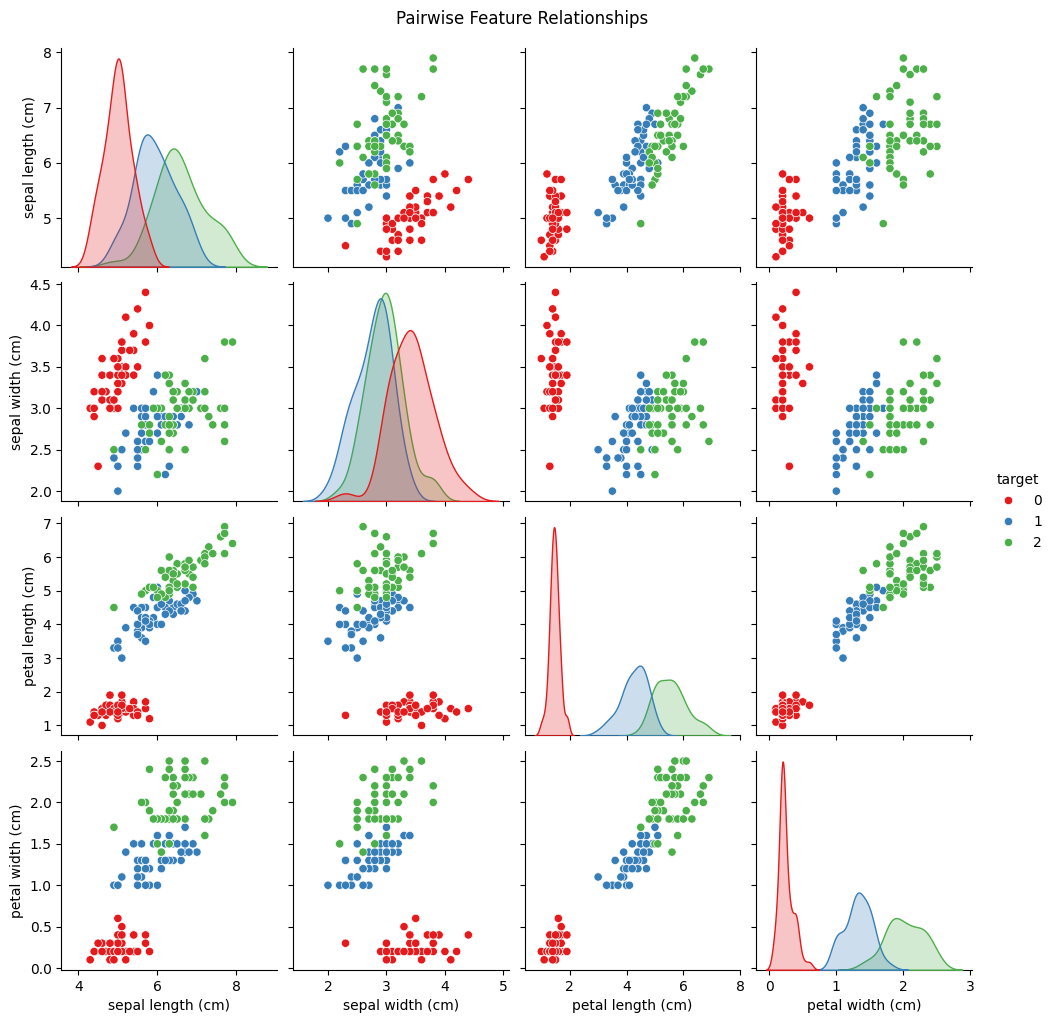

In [5]:
# Visualize feature distributions and pairwise relationships
import matplotlib.pyplot as plt
import seaborn as sns

# Histograms for each feature
df.drop('target', axis=1).hist(figsize=(10,8))
plt.suptitle('Feature Distributions')
plt.show()

# Pairplot colored by target class
sns.pairplot(df, hue='target', palette='Set1')
plt.suptitle('Pairwise Feature Relationships', y=1.02)
plt.show()

## Step 4: Prepare the Data
We will split the data into training and test sets, and scale the features for better neural network performance.

In [6]:
# Split the data and scale features
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features and target
X = df.drop('target', axis=1)
y = df['target']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Step 5: Build the Neural Network
We will use Keras (TensorFlow) to build a simple feedforward neural network. Best practices include:
- Using an input layer that matches the number of features
- Adding at least one hidden layer with ReLU activation
- Using softmax activation for multi-class classification
- Compiling with categorical crossentropy loss and accuracy metric

Let's start by importing the necessary libraries and setting a random seed for reproducibility.

In [7]:
# Import PyTorch and set random seed for reproducibility
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# Set random seeds
np.random.seed(42)
torch.manual_seed(42)

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


## Step 6: Prepare Data for PyTorch
We will convert the NumPy arrays to PyTorch tensors and create DataLoader objects for batching. This is a best practice for efficient training and evaluation.

In [8]:
# Convert data to PyTorch tensors and create DataLoaders
from torch.utils.data import TensorDataset, DataLoader

# Convert to tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

## Step 7: Define the Neural Network Architecture
We will define a simple feedforward neural network using PyTorch's `nn.Module` class. Best practices include:
- Input layer size matches number of features
- At least one hidden layer with ReLU activation
- Output layer size matches number of classes (3 for Iris)
- Use `nn.CrossEntropyLoss` for multi-class classification

In [10]:
# Professional feedforward neural network for Iris classification
class ProfessionalIrisNet(nn.Module):
    def __init__(self, input_size=4, hidden1=32, hidden2=16, dropout_p=0.3, num_classes=3):
        super(ProfessionalIrisNet, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden1)
        self.bn1 = nn.BatchNorm1d(hidden1)
        self.dropout1 = nn.Dropout(dropout_p)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.bn2 = nn.BatchNorm1d(hidden2)
        self.dropout2 = nn.Dropout(dropout_p)
        self.fc3 = nn.Linear(hidden2, num_classes)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout2(x)
        x = self.fc3(x)
        return x

# Instantiate the professional model and move to device
model = ProfessionalIrisNet().to(device)
print(model)

ProfessionalIrisNet(
  (fc1): Linear(in_features=4, out_features=32, bias=True)
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=32, out_features=16, bias=True)
  (bn2): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=16, out_features=3, bias=True)
  (relu): ReLU()
)


In [21]:
# Set up loss function, optimizer, and learning rate scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

print('Loss function:', criterion)
print('Optimizer:', optimizer)
print('Scheduler:', scheduler)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)
Scheduler: <torch.optim.lr_scheduler.ReduceLROnPlateau object at 0x7937a716fce0>


In [22]:
# Professional Trainer class for model training and validation
class Trainer:
    def __init__(self, model, criterion, optimizer, scheduler, device):
        self.model = model
        self.criterion = criterion
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.device = device
        self.train_losses = []
        self.val_losses = []
        self.train_accuracies = []
        self.val_accuracies = []

    def train(self, train_loader, val_loader, num_epochs=100):
        for epoch in range(num_epochs):
            train_loss, train_acc = self._train_one_epoch(train_loader)
            val_loss, val_acc = self._validate(val_loader)
            self.scheduler.step(val_loss)
            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)
            self.train_accuracies.append(train_acc)
            self.val_accuracies.append(val_acc)
            if (epoch+1) % 10 == 0 or epoch == 0:
                print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    def _train_one_epoch(self, loader):
        self.model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(self.device), y_batch.to(self.device)
            self.optimizer.zero_grad()
            outputs = self.model(X_batch)
            loss = self.criterion(outputs, y_batch)
            loss.backward()
            self.optimizer.step()
            running_loss += loss.item() * X_batch.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
        avg_loss = running_loss / total
        accuracy = correct / total
        return avg_loss, accuracy

    def _validate(self, loader):
        self.model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for X_batch, y_batch in loader:
                X_batch, y_batch = X_batch.to(self.device), y_batch.to(self.device)
                outputs = self.model(X_batch)
                loss = self.criterion(outputs, y_batch)
                running_loss += loss.item() * X_batch.size(0)
                _, predicted = torch.max(outputs, 1)
                correct += (predicted == y_batch).sum().item()
                total += y_batch.size(0)
        avg_loss = running_loss / total
        accuracy = correct / total
        return avg_loss, accuracy

# Instantiate and run the trainer
trainer = Trainer(model, criterion, optimizer, scheduler, device)
trainer.train(train_loader, test_loader, num_epochs=100)

Epoch 1/100 | Train Loss: 0.1195 | Train Acc: 0.9667 | Val Loss: 0.0694 | Val Acc: 1.0000
Epoch 10/100 | Train Loss: 0.1985 | Train Acc: 0.9583 | Val Loss: 0.0676 | Val Acc: 1.0000
Epoch 20/100 | Train Loss: 0.4655 | Train Acc: 0.8667 | Val Loss: 0.1229 | Val Acc: 0.9333
Epoch 30/100 | Train Loss: 0.2211 | Train Acc: 0.9000 | Val Loss: 0.0982 | Val Acc: 1.0000
Epoch 40/100 | Train Loss: 0.1752 | Train Acc: 0.9333 | Val Loss: 0.0963 | Val Acc: 1.0000
Epoch 50/100 | Train Loss: 0.2583 | Train Acc: 0.9083 | Val Loss: 0.0750 | Val Acc: 1.0000
Epoch 60/100 | Train Loss: 0.3385 | Train Acc: 0.8833 | Val Loss: 0.0800 | Val Acc: 1.0000
Epoch 70/100 | Train Loss: 0.1417 | Train Acc: 0.9500 | Val Loss: 0.0753 | Val Acc: 1.0000
Epoch 80/100 | Train Loss: 0.3483 | Train Acc: 0.8750 | Val Loss: 0.0827 | Val Acc: 1.0000
Epoch 90/100 | Train Loss: 0.1329 | Train Acc: 0.9583 | Val Loss: 0.0742 | Val Acc: 1.0000
Epoch 100/100 | Train Loss: 0.1788 | Train Acc: 0.9417 | Val Loss: 0.0748 | Val Acc: 1.0000

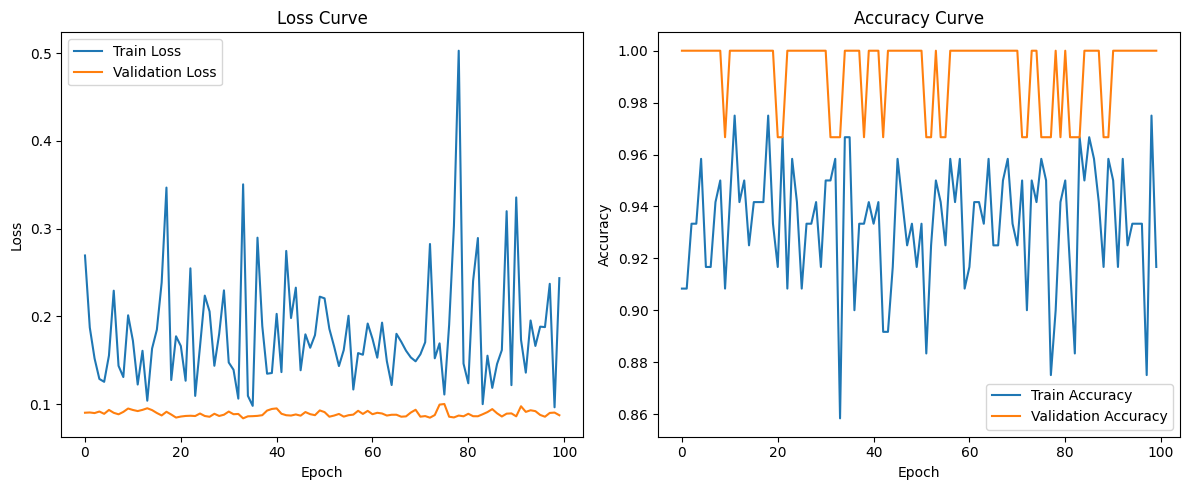

In [20]:
# Visualize training and validation loss and accuracy curves
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(trainer.train_losses, label='Train Loss')
plt.plot(trainer.val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

plt.subplot(1,2,2)
plt.plot(trainer.train_accuracies, label='Train Accuracy')
plt.plot(trainer.val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.tight_layout()
plt.show()

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


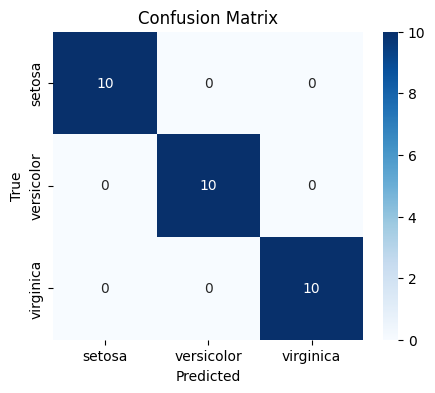

In [23]:
# Evaluate model: classification report and confusion matrix
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get all predictions and true labels from test set
model.eval()
preds = []
true = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        preds.extend(predicted.cpu().numpy())
        true.extend(y_batch.numpy())

# Classification report
print('Classification Report:')
print(classification_report(true, preds, target_names=data.target_names))

# Confusion matrix
cm = confusion_matrix(true, preds)
print('Confusion Matrix:')
print(cm)

# Optional: plot confusion matrix
import seaborn as sns
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [28]:

# Best practice: Save everything in a single checkpoint bundle
import torch
import joblib
import io
from datetime import datetime

# Capture scaler as bytes so it lives inside the .pt file
scaler_buffer = io.BytesIO()
joblib.dump(scaler, scaler_buffer)
scaler_bytes = scaler_buffer.getvalue()

# Bundle model weights, architecture config, preprocessing, and metadata
checkpoint = {
    # Model weights
    'model_state_dict': model.state_dict(),

    # Architecture config — required to reconstruct the model
    'model_config': {
        'input_size': 4,
        'hidden1': 32,
        'hidden2': 16,
        'dropout_p': 0.3,
        'num_classes': 3,
    },

    # Preprocessing — so it can't get out of sync with the weights
    'scaler_bytes': scaler_bytes,

    # Class label mapping
    'class_names': list(data.target_names),

    # Metadata for tracking
    'metadata': {
        'saved_at': datetime.now().isoformat(),
        'final_train_acc': round(trainer.train_accuracies[-1], 4),
        'final_val_acc': round(trainer.val_accuracies[-1], 4),
        'epochs': 100,
    },
}

torch.save(checkpoint, 'iris_checkpoint.pt')
print('Checkpoint saved to iris_checkpoint.pt')
print('Metadata:', checkpoint['metadata'])


Checkpoint saved to iris_checkpoint.pt
Metadata: {'saved_at': '2026-05-22T22:35:19.866748', 'final_train_acc': 0.9417, 'final_val_acc': 1.0, 'epochs': 100}


In [29]:

# Best practice: Load everything from a single checkpoint bundle
import torch
import torch.nn as nn
import joblib
import io
import numpy as np

# Load the checkpoint
# weights_only=False is required because the bundle contains non-tensor objects
# (scaler, class names, metadata). Only do this with checkpoints you created yourself.
checkpoint = torch.load('iris_checkpoint.pt', map_location=device, weights_only=False)

# Inspect metadata
print('Checkpoint metadata:', checkpoint['metadata'])

# Reconstruct model using saved config — no hardcoding needed
config = checkpoint['model_config']
model_loaded = ProfessionalIrisNet(**config).to(device)
model_loaded.load_state_dict(checkpoint['model_state_dict'])
model_loaded.eval()

# Restore scaler from embedded bytes
scaler_loaded = joblib.load(io.BytesIO(checkpoint['scaler_bytes']))

# Restore class names
class_names = checkpoint['class_names']
print('Classes:', class_names)

# Example inference — raw (unscaled) input
sample = np.array([[5.1, 3.5, 1.4, 0.2]])  # shape (1, 4)
sample_scaled = scaler_loaded.transform(sample)
sample_tensor = torch.tensor(sample_scaled, dtype=torch.float32).to(device)

with torch.no_grad():
    output = model_loaded(sample_tensor)
    pred = torch.argmax(output, dim=1).item()
    print('Predicted class:', class_names[pred])


Checkpoint metadata: {'saved_at': '2026-05-22T22:35:19.866748', 'final_train_acc': 0.9417, 'final_val_acc': 1.0, 'epochs': 100}
Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
Predicted class: setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [30]:

# Generate 10 fake samples and run batch inference using the loaded model
import pandas as pd
import numpy as np
import torch

# Fake data — realistic values within the Iris feature range
# Columns: sepal length, sepal width, petal length, petal width
fake_data = np.array([
    [5.1, 3.5, 1.4, 0.2],   # likely setosa
    [4.9, 3.0, 1.4, 0.2],   # likely setosa
    [7.0, 3.2, 4.7, 1.4],   # likely versicolor
    [6.4, 3.2, 4.5, 1.5],   # likely versicolor
    [6.3, 3.3, 6.0, 2.5],   # likely virginica
    [5.8, 2.7, 5.1, 1.9],   # likely virginica
    [5.0, 3.4, 1.5, 0.2],   # likely setosa
    [6.7, 3.1, 4.4, 1.4],   # likely versicolor
    [6.5, 3.0, 5.8, 2.2],   # likely virginica
    [5.5, 2.5, 4.0, 1.3],   # likely versicolor
])

feature_names = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
fake_df = pd.DataFrame(fake_data, columns=feature_names)

# Preprocess using the loaded scaler
fake_scaled = scaler_loaded.transform(fake_data)
fake_tensor = torch.tensor(fake_scaled, dtype=torch.float32).to(device)

# Run inference
model_loaded.eval()
with torch.no_grad():
    outputs = model_loaded(fake_tensor)
    probs = torch.softmax(outputs, dim=1)
    preds = torch.argmax(probs, dim=1).cpu().numpy()

# Build results table
fake_df['predicted_class'] = [class_names[p] for p in preds]
fake_df['confidence'] = probs.cpu().numpy().max(axis=1).round(4)

print(fake_df.to_string(index=True))


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm) predicted_class  confidence
0                5.1               3.5                1.4               0.2          setosa      0.9994
1                4.9               3.0                1.4               0.2          setosa      0.9980
2                7.0               3.2                4.7               1.4      versicolor      0.9715
3                6.4               3.2                4.5               1.5      versicolor      0.9705
4                6.3               3.3                6.0               2.5       virginica      0.9989
5                5.8               2.7                5.1               1.9       virginica      0.9621
6                5.0               3.4                1.5               0.2          setosa      0.9989
7                6.7               3.1                4.4               1.4      versicolor      0.9748
8                6.5               3.0                5.8       

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [32]:
# Model Card — rendered as styled HTML (Hugging Face style)
from IPython.display import display, HTML
from sklearn.metrics import classification_report
import torch

# Re-generate test set predictions so this cell is self-contained
# (avoids collisions with the fake-data inference cell above)
model.eval()
test_preds, test_true = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        test_preds.extend(predicted.cpu().numpy())
        test_true.extend(y_batch.numpy())

# Pull live metrics from training run and checkpoint
meta = checkpoint['metadata']
report = classification_report(test_true, test_preds, target_names=data.target_names, output_dict=True)
final_train_acc  = round(trainer.train_accuracies[-1] * 100, 2)
final_val_acc    = round(trainer.val_accuracies[-1]   * 100, 2)
final_train_loss = round(trainer.train_losses[-1], 4)
final_val_loss   = round(trainer.val_losses[-1],   4)

def metric_block(label, value, color="#4f8ef7"):
    return (
        f'<div style="background:#f8f9fa;border-left:4px solid {color};padding:10px 16px;'
        f'border-radius:6px;min-width:120px;">'
        f'<div style="font-size:11px;color:#6c757d;text-transform:uppercase;letter-spacing:0.5px;">{label}</div>'
        f'<div style="font-size:22px;font-weight:700;color:#212529;">{value}</div>'
        f'</div>'
    )

def class_row(name, d):
    return (
        f'<tr><td style="padding:6px 12px;font-weight:600;">{name}</td>'
        f'<td style="padding:6px 12px;text-align:center;">{d["precision"]:.2f}</td>'
        f'<td style="padding:6px 12px;text-align:center;">{d["recall"]:.2f}</td>'
        f'<td style="padding:6px 12px;text-align:center;">{d["f1-score"]:.2f}</td>'
        f'<td style="padding:6px 12px;text-align:center;">{int(d["support"])}</td></tr>'
    )

rows = "".join(class_row(n, report[n]) for n in data.target_names)
rows += class_row("macro avg", report["macro avg"])

metrics_html = "".join([
    metric_block("Val Accuracy",   f"{final_val_acc}%",    "#28a745"),
    metric_block("Train Accuracy", f"{final_train_acc}%",  "#4f8ef7"),
    metric_block("Val Loss",       final_val_loss,          "#fd7e14"),
    metric_block("Train Loss",     final_train_loss,        "#6f42c1"),
    metric_block("Macro F1",       f"{report['macro avg']['f1-score']:.2f}", "#20c997"),
    metric_block("Epochs",         meta["epochs"],          "#6c757d"),
])

card_html = f"""
<div style="font-family:'Segoe UI',sans-serif;max-width:860px;margin:20px auto;
            border:1px solid #dee2e6;border-radius:12px;overflow:hidden;
            box-shadow:0 2px 12px rgba(0,0,0,0.08);">

  <div style="background:linear-gradient(135deg,#1a1a2e 0%,#16213e 60%,#0f3460 100%);padding:28px 32px;">
    <div style="display:flex;gap:8px;margin-bottom:12px;">
      <span style="background:#4f8ef7;color:white;font-size:11px;font-weight:700;padding:3px 10px;border-radius:20px;">Classification</span>
      <span style="background:#28a745;color:white;font-size:11px;font-weight:700;padding:3px 10px;border-radius:20px;">PyTorch</span>
      <span style="background:#fd7e14;color:white;font-size:11px;font-weight:700;padding:3px 10px;border-radius:20px;">Iris Dataset</span>
    </div>
    <h1 style="color:white;margin:0 0 6px;font-size:26px;font-weight:800;">ProfessionalIrisNet</h1>
    <p style="color:#adb5bd;margin:0;font-size:14px;">Feedforward neural network for Iris species classification (3 classes)</p>
  </div>

  <div style="padding:28px 32px;background:white;">

    <h2 style="font-size:13px;font-weight:700;color:#495057;text-transform:uppercase;
               letter-spacing:0.8px;margin:0 0 12px;border-bottom:1px solid #dee2e6;padding-bottom:8px;">
      Performance Metrics
    </h2>
    <div style="display:flex;gap:10px;flex-wrap:wrap;margin-bottom:28px;">{metrics_html}</div>

    <h2 style="font-size:13px;font-weight:700;color:#495057;text-transform:uppercase;
               letter-spacing:0.8px;margin:0 0 12px;border-bottom:1px solid #dee2e6;padding-bottom:8px;">
      Per-Class Results — Test Set
    </h2>
    <table style="width:100%;border-collapse:collapse;font-size:14px;margin-bottom:28px;">
      <thead>
        <tr style="background:#f1f3f5;">
          <th style="padding:8px 12px;text-align:left;color:#495057;font-weight:600;">Class</th>
          <th style="padding:8px 12px;text-align:center;color:#495057;font-weight:600;">Precision</th>
          <th style="padding:8px 12px;text-align:center;color:#495057;font-weight:600;">Recall</th>
          <th style="padding:8px 12px;text-align:center;color:#495057;font-weight:600;">F1-Score</th>
          <th style="padding:8px 12px;text-align:center;color:#495057;font-weight:600;">Support</th>
        </tr>
      </thead>
      <tbody>{rows}</tbody>
    </table>

    <h2 style="font-size:13px;font-weight:700;color:#495057;text-transform:uppercase;
               letter-spacing:0.8px;margin:0 0 12px;border-bottom:1px solid #dee2e6;padding-bottom:8px;">
      Architecture
    </h2>
    <div style="background:#f8f9fa;border-radius:8px;padding:16px 20px;font-size:13px;margin-bottom:28px;">
      <table style="width:100%;border-collapse:collapse;">
        <tr><td style="padding:5px 0;color:#6c757d;width:180px;">Input features</td><td style="font-weight:600;">4 (sepal/petal length &amp; width)</td></tr>
        <tr><td style="padding:5px 0;color:#6c757d;">Hidden layers</td><td style="font-weight:600;">2 &nbsp;&#8594;&nbsp; 32 units &#8594; 16 units</td></tr>
        <tr><td style="padding:5px 0;color:#6c757d;">Activations</td><td style="font-weight:600;">ReLU + BatchNorm1d + Dropout (p=0.3)</td></tr>
        <tr><td style="padding:5px 0;color:#6c757d;">Output</td><td style="font-weight:600;">3 classes via CrossEntropyLoss</td></tr>
        <tr><td style="padding:5px 0;color:#6c757d;">Optimizer</td><td style="font-weight:600;">Adam (lr=0.01)</td></tr>
        <tr><td style="padding:5px 0;color:#6c757d;">Scheduler</td><td style="font-weight:600;">ReduceLROnPlateau (patience=10, factor=0.5)</td></tr>
        <tr><td style="padding:5px 0;color:#6c757d;">Batch size</td><td style="font-weight:600;">16</td></tr>
      </table>
    </div>

    <h2 style="font-size:13px;font-weight:700;color:#495057;text-transform:uppercase;
               letter-spacing:0.8px;margin:0 0 12px;border-bottom:1px solid #dee2e6;padding-bottom:8px;">
      Training Data
    </h2>
    <div style="background:#f8f9fa;border-radius:8px;padding:16px 20px;font-size:13px;margin-bottom:28px;">
      <table style="width:100%;border-collapse:collapse;">
        <tr><td style="padding:5px 0;color:#6c757d;width:180px;">Dataset</td><td style="font-weight:600;">UCI Iris (via sklearn.datasets)</td></tr>
        <tr><td style="padding:5px 0;color:#6c757d;">Total samples</td><td style="font-weight:600;">150 (50 per class)</td></tr>
        <tr><td style="padding:5px 0;color:#6c757d;">Train / Test split</td><td style="font-weight:600;">80% / 20% &nbsp; stratified, random_state=42</td></tr>
        <tr><td style="padding:5px 0;color:#6c757d;">Preprocessing</td><td style="font-weight:600;">StandardScaler — fit on train only (no leakage)</td></tr>
        <tr><td style="padding:5px 0;color:#6c757d;">Classes</td><td style="font-weight:600;">setosa &nbsp;|&nbsp; versicolor &nbsp;|&nbsp; virginica</td></tr>
      </table>
    </div>

    <div style="font-size:12px;color:#adb5bd;border-top:1px solid #dee2e6;padding-top:14px;">
      Saved: {meta['saved_at']} &nbsp;&#183;&nbsp; Checkpoint: <code>iris_checkpoint.pt</code>
    </div>
  </div>
</div>
"""

display(HTML(card_html))
